In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import os
from tqdm import tqdm
from scipy.special import logsumexp
from scipy.stats import poisson


%matplotlib widget

In [2]:

class custom_PoissonHMM:
    
    def __init__(self, A, B, pi, eps=1e-12):
        '''
        Initialize the HMM with the transition matrix (A), emission probability matrix (B) and prior probability distribution (pi)
        '''
        self.eps = eps

        self.A = np.array(A)
        self.log_A = np.log(A + self.eps)
        self.log_A[self.A == 0] = -np.inf # setting any zero entries in A to -inf in log-space

        self.B = np.array(B)

        self.pi = np.array(pi)
        self.log_pi = np.log(self.pi)

        self.N = self.A.shape[0]

        self.obs = None
        self.T = 0

        self.log_emissions = None


    def generate_samples(self, Nsamples):
        '''generate a random markov chain from the transition matrix A and sample obervations from each hidden state'''

        # initialize the hidden states
        hidden_states = np.zeros(Nsamples, dtype=int)
        hidden_states[0] = np.random.choice(self.N, p = self.pi)

        # initialize the obervations
        obervations = np.zeros((Nsamples, self.B.shape[1]))
        obervations[0] = np.random.poisson(lam = self.B[hidden_states[0]])

        for t in range(1, Nsamples):
            hidden_states[t] = np.random.choice(self.N, p=self.A[hidden_states[t-1]])
            obervations[t] = np.random.poisson(lam = self.B[hidden_states[t]])

        return hidden_states, obervations


    def compute_emissions(self):
        '''compute the emission probabilities of the observations given the emission probability matrix (B)'''

        self.log_emissions_by_dim = poisson.logpmf(
            self.obs[:, None, :],
            self.B[None, :, :]
        )

        self.log_emissions = self.log_emissions_by_dim.sum(axis=2)

    
    def set_observations(self, obs):

        self.obs = np.asarray(obs)
        self.T = len(obs)

        self.compute_emissions()
    

    def forward_probability(self):
        '''
        computes the logarithm of the forward probabilities (alpha) of the observations given the hmm
        '''

        # initialize the forward probabilities
        log_alpha = np.zeros((self.T, self.N))
        log_alpha[0] = (
            self.log_pi
            + self.log_emissions[0]
        )

        # run recursion to solve the rest
        for t in range(1, self.T):

            # compute the next forward probability
            log_alpha[t] = (
                logsumexp(
                    log_alpha[t-1][:,None]
                    + self.log_A, axis = 0
                )
                + self.log_emissions[t]
            )

        return log_alpha
    
    
    def backward_probability(self):
        '''
        compute the logarithm of the backward probabilities (beta) of the observations given the hmm
        '''

        # initialize the backward probabilities
        log_beta = np.zeros((self.T, self.N))
        log_beta[-1] = 0.0 # log(1) = n0

        for t in range(self.T - 2, -1, -1):
            
            # compute the previous backward probability
            log_beta[t] = logsumexp(
                self.log_emissions[t + 1][None, :]
                + self.log_A
                + log_beta[t + 1][None, :],
                axis = 1
            ) 
        
        return log_beta
    

    def viterbi(self):
        '''
        using the viterbi algorithm in log-space to find the latent variables which maximize the probability of the emission sequence
        '''

        # initialize the viterbi and the backpointers
        log_viterbi = np.zeros((self.T, self.N))
        backpointers = np.zeros((self.T, self.N), dtype=int)

        log_viterbi[0] = (
            self.log_pi 
            + self.log_emissions[0]
        )
        

        # run the recursion 
        for t in range(1, self.T):
            log_values = np.array(
                log_viterbi[t - 1][:, None]
                + self.log_A
            )
            
            log_viterbi[t] = np.max(log_values, axis = 0) + self.log_emissions[t]
            backpointers[t] = np.argmax(log_values, axis = 0)

        # inbitialize the most likely states
        states = np.zeros(self.T, dtype = int)
        states[-1] = np.argmax(log_viterbi[-1])

        # loop backwards over time and use the backpointers to find the most likely state sequence
        for t in range(self.T - 1, 0, -1):
            states[t - 1] = backpointers[t, states[t]]

        return states
    

    def compute_log_xi(self, log_alpha, log_beta):

        log_likelihood = logsumexp(log_alpha[-1])  # scalar

        log_xi = (
            log_alpha[:-1, :, None]          # (T-1) x N x 1
            + self.log_A[None, :, :]         # 1 x N x N
            + self.log_emissions[1:, None, :] # (T-1) x 1 x N
            + log_beta[1:, None, :]          # (T-1) x 1 x N
            - log_likelihood
        )

        # normalize
        log_xi -= logsumexp(
            log_xi,
            axis=(1,2),
            keepdims=True
        )

        return log_xi # (T-1) x N x N


    def compute_log_gamma(self, log_alpha, log_beta):
        

        log_gamma = (
            log_alpha       # T x N
            + log_beta      # T x N
        )

        # Normalize
        log_gamma -= logsumexp(
            log_gamma,
            axis=1,
            keepdims=True
        )

        return log_gamma # T x N
    

    def forward_backward(self, transition_update_mask = None, save_dir = None, use_cloned_emissions = False):
        '''using the forward backward algorithm to update the transition matrix (A) and the emissions matrix (B) using the forward and backwards probabilities'''

        #---------------------------Expectation----------------------------------

        # compute the forward and reverse probabilities
        self.log_alpha = self.forward_probability()   # T x N
        self.log_beta = self.backward_probability()   # T x N


        # compuite xi
        log_xi = self.compute_log_xi(self.log_alpha, self.log_beta) # (T-1) x N x N

        if transition_update_mask is not None:
            log_xi = np.where(
                transition_update_mask,
                log_xi,
                -np.inf
            )

        # compute gamma
        log_gamma = self.compute_log_gamma(self.log_alpha, self.log_beta) # T x N

        if save_dir is not None:
            # plot the xi values as a heatmap
            avg_log_xi = logsumexp(log_xi, axis=0) - np.log(log_xi.shape[0]) # N x N
            avg_xi = np.exp(avg_log_xi)
            plt.figure(figsize=(22, 20))
            sns.heatmap(avg_xi, annot=True, fmt=".1e", cmap="Greys" )
            plt.title("Average Xi Values (Transition Probabilities)")
            plt.xlabel("Next State")
            plt.ylabel("Current State")
            plt.savefig(os.path.join(save_dir, "average_xi_heatmap.png"))
            plt.close()



        #---------------------------Maximization---------------------------------

        # numerator
        log_sum_xi = logsumexp(log_xi, axis = 0)      # N x N

        # denominator
        log_row_norm = logsumexp(log_sum_xi, axis=1)  # N

        log_A_hat = (
            log_sum_xi  # N x N
            - log_row_norm[:, None] # N x 1
        )


        A_hat = np.exp(log_A_hat)

        # explicitly set any zero entries in the transition matrix to zero to avoid numerical issues with very small probabilities
        if transition_update_mask is not None:
            A_hat = np.where(
                transition_update_mask,
                A_hat,
                0.0
            )


        gamma = np.exp(log_gamma)

        if use_cloned_emissions:\
        
            nSequenceStates = (self.N - 1) // 2
            B_hat = np.zeros_like(self.B)
            mu_hat = np.zeros((nSequenceStates, self.B.shape[1]))

            # solving for the clone emissions states
            for i in range(nSequenceStates):
                w = gamma[:, i + 1] + gamma[:, nSequenceStates + i + 1]

                mu_hat[i] = (
                    w[:, None] * self.obs
                ).sum(axis=0) / w.sum()

                B_hat[i + 1] = mu_hat[i]
                B_hat[nSequenceStates + i + 1] = mu_hat[i]


            # estimating the base state
            B_hat[0] = (
                gamma[:, 0][:, None] * self.obs
            ).sum(axis=0) / gamma[:, 0].sum()

                
        else:
            B_hat = (
                gamma.T @ self.obs
                / gamma.sum(axis=0)[:, None]
            ) # N x D

            
        return A_hat, B_hat
    

    def fit_em(self, Niters, use_cloned_emissions = False, transition_update_mask = None, save_dir = None):
        '''fit the transition and emissions matrices using expectation maximization'''

        llhs = np.zeros(Niters + 1)
        llhs[0] = logsumexp(self.forward_probability()[-1])
        for iter in tqdm(range(Niters)):

            if save_dir is not None:
                current_save_dir = os.path.join(save_dir, f"iteration_{iter}")
                os.makedirs(current_save_dir, exist_ok=True)
            else:
                current_save_dir = None


            # run the forward backwards pass
            A_hat, B_hat = self.forward_backward(transition_update_mask = transition_update_mask, save_dir = current_save_dir, use_cloned_emissions = use_cloned_emissions)

            # update the transition matrix
            self.A = A_hat
            if transition_update_mask is not None:
                self.log_A = np.where(
                    transition_update_mask,
                    np.log(self.A + self.eps),
                    -np.inf
                )
                self.A[~transition_update_mask] = 0.0

            else:
                self.log_A = np.log(self.A + self.eps)

            # update the emissions matrix
            self.B = B_hat

            # recompute the emissions
            self.compute_emissions()

            log_alpha = self.forward_probability()

            # compute the log-likelihood
            llhs[iter + 1] = logsumexp(log_alpha[-1])

        return llhs




In [3]:

def calculate_cloned_transition_matrix(alpha, sequenceLength, nSequences, verbose=False, transition_epsilon=1e-8):

    # the total number of states is the number of sequences times the sequence length and we add one for the non-sequence state
    nStates = sequenceLength * nSequences + 1

    gamma = (1 - alpha) / (2 * sequenceLength * nSequences) # this is the probability of transitioning into or out of any of the sequence states
    beta = 1 - gamma # this is the probability of transitioning between states in the sequence
    if verbose:
        print(f"alpha: {alpha}, beta: {beta}, gamma: {gamma}")

    # initialize the transition matrix with zeros and then fill in the appropriate entries
    P = np.zeros((1 + 2 * sequenceLength * nSequences, 1 + 2 * sequenceLength * nSequences))
    P[0, 0] = alpha

    # define the transition probabilities into the sequences (can transition into any part of the sequence with equal probability)
    P[0, 1:] = gamma

    # define the transition probabilities out of the sequences (can transition out of any part of the sequence with equal probability)
    P[1:, 0] = gamma

    # define the transition probabilities through the sequences
    start = None
    for i in range(nSequences):
        start = 1 if start is None else end + 1
        end = start + 2 * sequenceLength - 1

        for idx, j in enumerate(range(start, end + 1)):

            # set the beta values for the forward sequence
            if idx < sequenceLength - 1:
                P[j, j + 1] = beta

            # set the beta values for the reverse sequence (these are the cloned states that have the same emission probabilities as the forward sequence states)
            elif idx > sequenceLength:
                P[j, j - 1] = beta
            else:
                P[j, 0] = 1

    # Tiny smoothing avoids exact zeros that can make EM objective report -inf via log(0).
    if transition_epsilon is not None and transition_epsilon > 0:
        P = P + transition_epsilon
        P = P / P.sum(axis=1, keepdims=True)

    return P


alpha: 0.1, beta: 0.955, gamma: 0.045


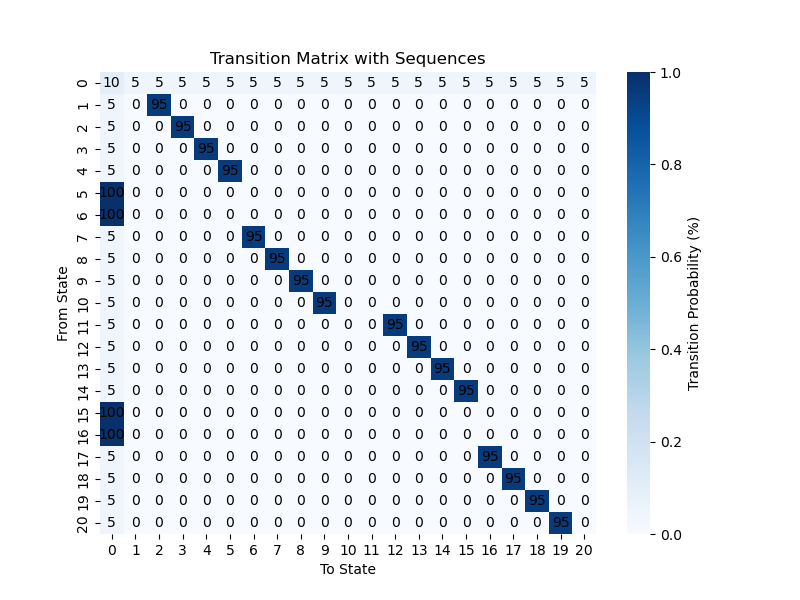

In [4]:

alpha = 0.1 # this is the probability of staying in the non sequence state. This is the only free parameter we have to set, the rest of the transition probabilities are determined by this and the sequence length and number of sequences
sequenceLength = 5 # number of latent states in each sequence
nSequences = 2 # total number of sequences

# Compute the transition matrix given the free paramerters
P = calculate_cloned_transition_matrix(alpha, sequenceLength, nSequences, verbose=True)
nStates = P.shape[0]

# plot the transition matrix
plt.figure(figsize=(8, 6))
sns.heatmap(P, cmap="Blues", cbar_kws={"label": "Transition Probability (%)"}, vmin=0, vmax=1)
# overlay the numbers for the transition probabilities
for i in range(nStates):
    for j in range(nStates):
        plt.text(j + 0.5, i + 0.5, f"{(P[i, j] * 100):.0f}", ha="center", va="center", color="black")
plt.title("Transition Matrix with Sequences")
plt.xlabel("To State")
plt.ylabel("From State")

plt.show()

In [5]:
# simulate data from this transition matrix
Nsteps = 2_000
states = np.zeros(Nsteps, dtype=int)
for t in range(1, Nsteps):
    states[t] = np.random.choice(nStates, p=P[states[t-1]])

(21, 100)
[(1, 6), (2, 7), (3, 8), (4, 9), (5, 10), (11, 16), (12, 17), (13, 18), (14, 19), (15, 20)]


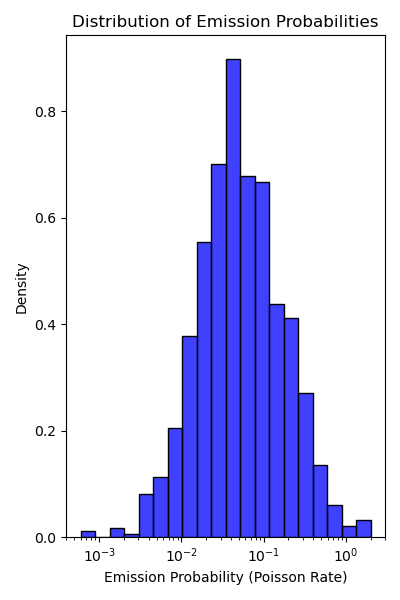

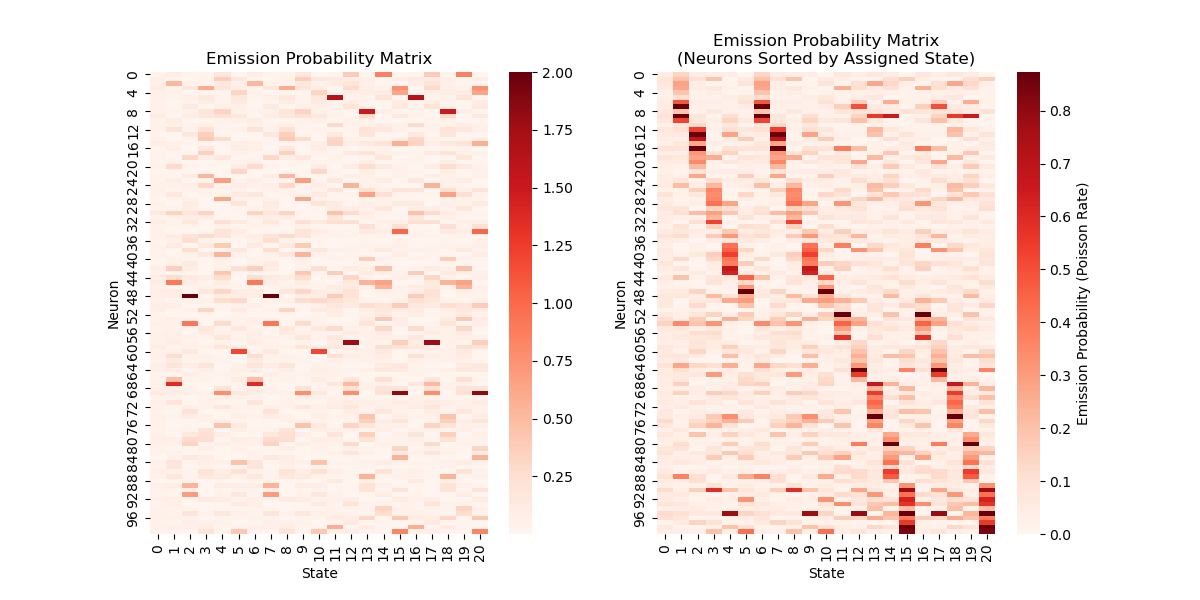

In [6]:
plot_len = 100

# randomly initialize the emission probabilities (poisson rates for each state and each neuron)
emission_dim = 100 # this corresponds to the number of neurons we are simulating

# draw the lambda parameters for the Poisson emissions from a lognormal distribution (this is a common choice for a prior on Poisson rates)
emission_prob = np.zeros((nStates, emission_dim))
print(emission_prob.shape)

nStates = P.shape[0]
pairs = []
for seq in range(nSequences):
    for step in range(sequenceLength):
        new_pair = (seq * 2 * sequenceLength + step + 1, seq * 2 * sequenceLength  + sequenceLength + step + 1)
        pairs.append(new_pair)
print(pairs)

for pair in pairs:
    # set the emission probabilities for the paired states to be the same (these are the cloned states that have the same emissions as the forward sequence states)
    emissions = np.random.lognormal(
        mean=-3,
        sigma=1.2,
        size=(emission_dim,)
    )
    # clip the emissions at 2Hz
    emissions = emissions.clip(0, 2)
    emission_prob[pair[1], :], emission_prob[pair[0], :] = emissions, emissions

# set the emission prob in state zero to be the median across all the other states
emission_prob[0, :] = np.median(emission_prob[1:, :], axis=0)


# plot the distribution of emission probabilities for each state
plt.figure(figsize=(4, 6))
sns.histplot(emission_prob.flatten(), bins=20, stat='density', log_scale=(True, False), color="blue", edgecolor="black")
plt.title("Distribution of Emission Probabilities")
plt.xlabel("Emission Probability (Poisson Rate)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

# simulate emissions from the HMM given the state sequence and the emission probabilities
emissions = np.zeros((Nsteps, emission_dim), dtype=int)
for t in range(Nsteps):
    emissions[t] = np.random.poisson(lam=emission_prob[states[t]])


# plot the emission prob matrix
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(emission_prob.T, cmap="Reds", ax=axs[0])
axs[0].set_title("Emission Probability Matrix")
axs[0].set_xlabel("State")
axs[0].set_ylabel("Neuron")

# assign neurons to states (for each neuron, the state of maximal firing is the state that neuron is assigned to)
neuron_states = np.argmax(emission_prob, axis=0)

# sort the neurons by their assigned states and plot the emision prob matrix again
sorted_indices = np.argsort(neuron_states)
sns.heatmap(emission_prob[:, sorted_indices].T, cmap="Reds", ax=axs[1], cbar_kws={"label": "Emission Probability (Poisson Rate)"}, vmin=0, vmax=np.percentile(emission_prob, 99))
axs[1].set_title("Emission Probability Matrix\n(Neurons Sorted by Assigned State)")
axs[1].set_xlabel("State")
axs[1].set_ylabel("Neuron")
plt.show()



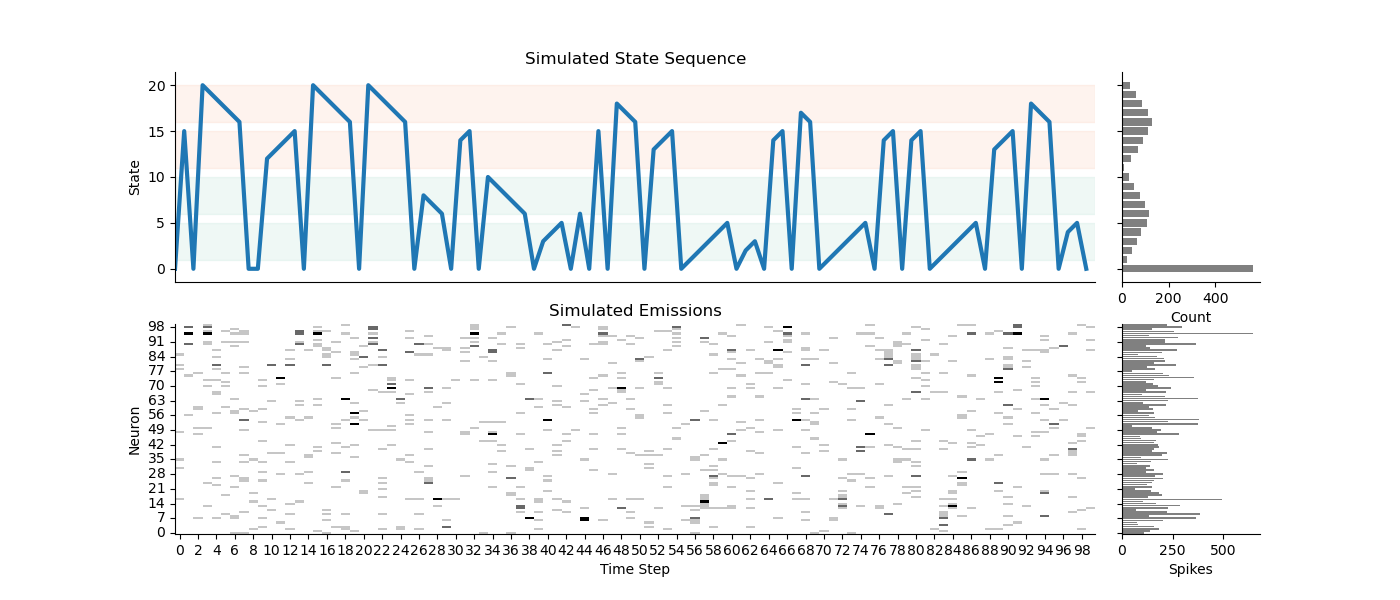

In [7]:
from matplotlib.gridspec import GridSpec

seq_colors = sns.color_palette("Set2", nSequences)

# Sort neurons by assigned state
sorted_indices = np.argsort(neuron_states)

# ----------------------------------
# Counts over ENTIRE dataset
# ----------------------------------

# State occupancy counts
state_counts = np.bincount(states, minlength=np.max(states)+1)

# Total spikes/emissions per neuron
neuron_counts = emissions.sum(axis=0)
neuron_counts_sorted = neuron_counts[sorted_indices]

# ----------------------------------
# Figure layout
# ----------------------------------

fig = plt.figure(figsize=(14, 6))
gs = GridSpec(
    2, 2,
    width_ratios=[20, 3],
    height_ratios=[1, 1],
    hspace=0.2,
    wspace=0.05
)

ax_state = fig.add_subplot(gs[0, 0])
ax_emiss = fig.add_subplot(gs[1, 0], sharex=ax_state)

ax_state_hist = fig.add_subplot(gs[0, 1], sharey=ax_state)
ax_emiss_hist = fig.add_subplot(gs[1, 1], sharey=ax_emiss)

# ----------------------------------
# Main plots
# ----------------------------------

sns.lineplot(
    x=np.arange(plot_len),
    y=states[:plot_len],
    ax=ax_state,
    linewidth=3
)

ax_state.set_title("Simulated State Sequence")
ax_state.set_ylabel("State")
ax_state.tick_params(
    axis='x',
    which='both',
    bottom=False,
    top=False,
    labelbottom=False
)


sns.heatmap(
    emissions[:plot_len, sorted_indices].T,
    cmap="Greys",
    ax=ax_emiss,
    vmax=3,
    cbar=False
)

ax_emiss.invert_yaxis()
ax_emiss.set_title("Simulated Emissions")
ax_emiss.set_xlabel("Time Step")
ax_emiss.set_ylabel("Neuron")

# ----------------------------------
# Histograms on right
# ----------------------------------

# State occupancy histogram
ax_state_hist.barh(
    np.arange(len(state_counts)),
    state_counts,
    color='gray'
)
ax_state_hist.set_xlabel("Count")

# Neuron firing histogram
ax_emiss_hist.barh(
    np.arange(len(neuron_counts_sorted)) + 0.5,
    neuron_counts_sorted,
    color='gray'
)
ax_emiss_hist.set_xlabel("Spikes")

# Clean up histogram axes
ax_state_hist.tick_params(labelleft=False)
ax_emiss_hist.tick_params(labelleft=False)

# ----------------------------------
# Sequence shading
# ----------------------------------

for i in range(nSequences):

    forward_start = 1 + i * 2 * sequenceLength
    forward_end = forward_start + sequenceLength

    reverse_start = forward_end
    reverse_end = reverse_start + sequenceLength

    ax_state.axhspan(
        forward_start,
        forward_end - 1,
        color=seq_colors[i],
        alpha=0.1
    )

    ax_state.axhspan(
        reverse_start,
        reverse_end - 1,
        color=seq_colors[i],
        alpha=0.1
    )

sns.despine()
plt.show()

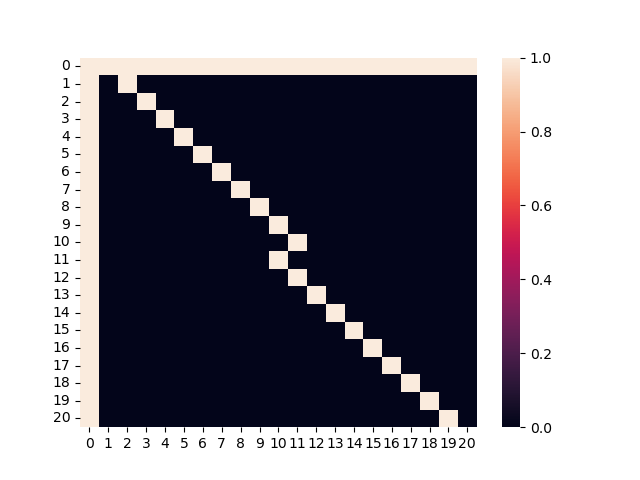

In [8]:
# fit the model with the correct hyperparameters
save_dir = r'C:\Users\srafi\OneDrive\NeuroStatsLab\sequence-detection-figures\custom-HMM-fit-to-cloned-100-emission-5sequenceLength-2_000samples-enforce-cloned-emissions-sparse-initialize-5-27-26'
use_cloned_emissions = True # whether to enforce that the cloned states have the same emissions

Niters = 40
nStarts = 50

# compute the transition matrix given the free parameters
P = calculate_cloned_transition_matrix(
    alpha,
    sequenceLength,
    nSequences
)
best_ll = -np.inf
best_model = None
best_params = None
all_lls = []

N = P.shape[0]

# make the transition update mask (true = update, false = freeze)
transition_update_mask = np.zeros_like(P, dtype = bool)
transition_update_mask[0,:] = True
transition_update_mask[:, 0] = True

nSequenceStates = (N - 1) // 2
for i in range(nSequenceStates):
    transition_update_mask[i + 1, i + 2] = True
    transition_update_mask[nSequenceStates + i + 1, nSequenceStates + i] = True

plt.figure()
sns.heatmap(transition_update_mask)
plt.show()

In [9]:
for seed in range(nStarts):

    current_save_dir = os.path.join(save_dir, f"restart_{seed}")
    os.makedirs(current_save_dir, exist_ok=True)

    # set random seed for reproducibility
    np.random.seed(seed)

    # draw random initial transition matrix from a dirichlet distribution
    initial_A = np.random.dirichlet(np.ones(N), size=N)

    # Set the off-diagonal and non-sequence transitions to zero to enforce the structure of the cloned transition matrix
    initial_A = np.where(
        transition_update_mask,
        initial_A,
        0.0
    )

    # renormalize the rows to sum to 1
    row_sums = initial_A.sum(axis=1, keepdims=True)
    if np.any(row_sums == 0):
        raise ValueError("At least one row of initial_A has no allowed transitions.")
    initial_A = initial_A / row_sums


    #set the initial_emission_rates as the mean rate for each neuron across all time points
    initial_emission_rates = emissions.mean(axis=0)

    # convert to matrix with shape (nStates, emission_dim)
    initial_emission_rates = np.repeat(initial_emission_rates[None, :], nStates, axis=0)

    # add some noise to the initial rates to break symmetry
    initial_emission_rates += 1e-6 * np.random.normal(size=initial_emission_rates.shape)

    # make sure all rates are positive
    initial_emission_rates = np.clip(initial_emission_rates, a_min=1e-9, a_max=3)

    # initialize the prior probabilties pi
    initial_pi = np.ones(N) / N

    
    # define the model
    hmm = custom_PoissonHMM(
        initial_A,
        initial_emission_rates,
        initial_pi,
    )

    # set the observations
    hmm.set_observations(emissions)



    # run the baum-welch algorithm with cloned states
    lls = hmm.fit_em(Niters=Niters, use_cloned_emissions=True, transition_update_mask=transition_update_mask, save_dir=None)



    # plot the EM convergence
    plt.figure()
    plt.plot(np.asarray(lls))
    plt.title(f"EM Convergence for Restart {seed + 1}")
    plt.xlabel("EM Iteration")
    plt.ylabel("Log-Likelihood")
    plt.tight_layout()
    plt.savefig(os.path.join(current_save_dir, f"em_convergence.png"))
    plt.close()

    # plot the transition matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(np.array(hmm.A), cmap="Blues", cbar_kws={"label": "Transition Probability (%)"}, vmin=0, vmax=1)
    # overlay the numbers for the transition probabilities
    for i in range(nStates):
        for j in range(nStates):
            plt.text(j + 0.5, i + 0.5, f"{(hmm.A[i, j] * 100):.0f}", ha="center", va="center", color="black")
    plt.title("Learned Transition Matrix")
    plt.xlabel("To State")
    plt.ylabel("From State")
    plt.tight_layout()
    plt.savefig(os.path.join(current_save_dir, f"learned_transition_matrix.png"))
    plt.close()

    all_lls.append(lls[-1])
    if lls[-1] > best_ll:
        best_ll = lls[-1]
        best_model = hmm





100%|██████████| 40/40 [00:20<00:00,  1.91it/s]


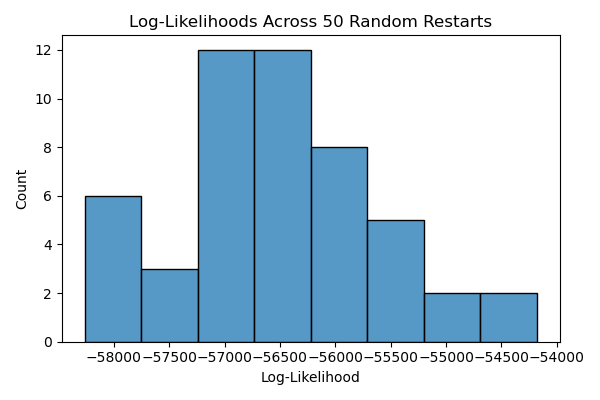

In [10]:
# plot the distribution of log-likelihoods across random restarts
plt.figure(figsize=(6, 4))
sns.histplot(np.array(all_lls), stat='count')
plt.title("Log-Likelihoods Across 50 Random Restarts")
plt.xlabel("Log-Likelihood")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [11]:
hmm = best_model

# get the inferred state sequence
inferred_states = hmm.viterbi()


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20] [ 0 10  1  2  3  4 20 11 12 13 14  9  8  7  6  5 19 18 17 16 15]
Mean matched distance: 0.01296525096447994


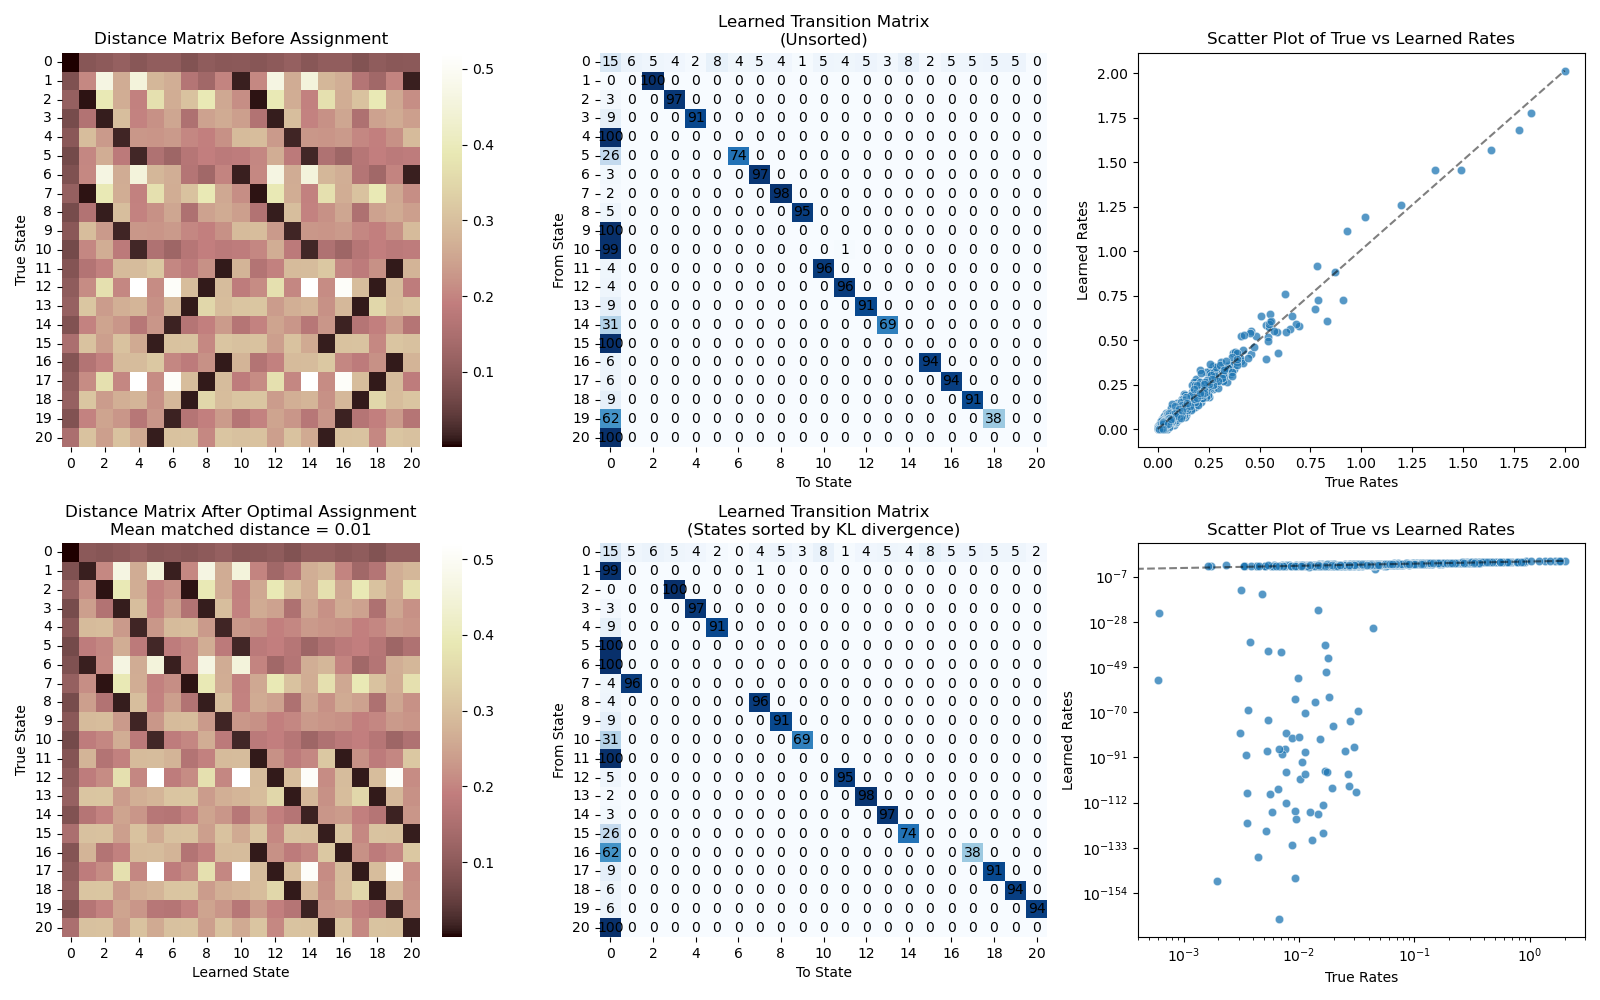

In [12]:
from scipy.optimize import linear_sum_assignment

def poisson_distance(true_rates, learned_rates, eps=1e-5):
    distance_matrix = np.zeros((true_rates.shape[0], learned_rates.shape[0]))
    for i in range(true_rates.shape[0]):
        for j in range(learned_rates.shape[0]):
            # compute the poisson distance between the true and learned rates for this state pair
            distance_matrix[i, j] = ((np.log(true_rates[i] + eps) - np.log(learned_rates[j] + eps))**2).mean()
    return distance_matrix


def poisson_kl_divergence(true_rates, learned_rates, eps=1e-8):
    """
    Computes KL divergence between multivariate independent Poisson emission models.

    true_rates:    shape (n_true_states, n_features)
    learned_rates: shape (n_learned_states, n_features)

    Returns:
        divergence_matrix[i, j] =
        KL(Poisson(true_rates[i]) || Poisson(learned_rates[j]))
    """

    true_rates = np.asarray(true_rates, dtype=float)
    learned_rates = np.asarray(learned_rates, dtype=float)

    divergence_matrix = np.zeros((true_rates.shape[0], learned_rates.shape[0]))

    for i in range(true_rates.shape[0]):
        lam = true_rates[i] + eps

        for j in range(learned_rates.shape[0]):
            lam_hat = learned_rates[j] + eps

            divergence_matrix[i, j] = np.mean(
                lam * np.log(lam / lam_hat) + lam_hat - lam
            )

    return divergence_matrix
# get the learned emission probabilities from the best model
learned_emission_prob = np.array(hmm.B)

true_rates = emission_prob
learned_rates = np.array(learned_emission_prob)

# distance matrix
distance_matrix = poisson_kl_divergence(
    true_rates,
    learned_rates
)



# Hungarian assignment minimizes total distance
row_ind, col_ind = linear_sum_assignment(distance_matrix)

print(row_ind, col_ind)

matching_distances = distance_matrix[row_ind, col_ind]

print("Mean matched distance:", matching_distances.mean())

# plot the original and matched correlation matrices
fig, axs = plt.subplots(2, 3, figsize=(16, 10))
sns.heatmap(distance_matrix, cmap="pink", cbar_kws={"label": "Distance"},  ax=axs[0,0])
axs[0,0].set_title("Distance Matrix Before Assignment")
sns.heatmap(distance_matrix[:, col_ind], cmap="pink", cbar_kws={"label": "Distance"}, ax=axs[1,0])
axs[1,0].set_title("Distance Matrix After Optimal Assignment\nMean matched distance = {:.2f}".format(matching_distances.mean()))
axs[0,0].set_xlabel("")
axs[0,0].set_ylabel("True State")
axs[1,0].set_xlabel("Learned State")
axs[1,0].set_ylabel("True State")
#colorbar label
axs[0,0].collections[0].colorbar.set_label("")
axs[1,0].collections[0].colorbar.set_label("")


# plot scatterplot of true and learned rates after sorting
axs[0,2].plot([0, np.max(true_rates)], [0, np.max(learned_rates)], 'k--', alpha=0.5)
sns.scatterplot(x=true_rates[row_ind, :].flatten(), y=learned_rates[col_ind, :].flatten(), ax=axs[0,2], alpha=0.5)
axs[0,2].set_title("Scatter Plot of True vs Learned Rates")
axs[0,2].set_xlabel("True Rates")
axs[0,2].set_ylabel("Learned Rates")


# plot scatterplot of true and learned rates after sorting
axs[1,2].plot([0, np.max(true_rates)], [0, np.max(learned_rates)], 'k--', alpha=0.5)
sns.scatterplot(x=true_rates[row_ind, :].flatten(), y=learned_rates[col_ind, :].flatten(), ax=axs[1,2], alpha=0.5)
axs[1,2].set_yscale('log')
axs[1,2].set_xscale('log')
axs[1,2].set_title("Scatter Plot of True vs Learned Rates")
axs[1,2].set_xlabel("True Rates")
axs[1,2].set_ylabel("Learned Rates")

# plot the sorted transition matrix
sns.heatmap(np.array(hmm.A)[col_ind][:, col_ind], cmap="Blues", cbar_kws={"label": "Transition Probability (%)"}, vmin=0, vmax=1, ax=axs[1,1])
# overlay the numbers for the transition probabilities
for i in range(nStates):
    for j in range(nStates):
        axs[1,1].text(j + 0.5, i + 0.5, f"{(hmm.A[col_ind][:, col_ind][i, j] * 100):.0f}", ha="center", va="center", color="black")
axs[1,1].set_title("Learned Transition Matrix\n(States sorted by KL divergence)")
axs[1,1].set_xlabel("To State")
axs[1,1].set_ylabel("From State")
# remove colorbar
axs[1,1].collections[0].colorbar.remove()
#plot the unsorted transition matrix
sns.heatmap(np.array(hmm.A), cmap="Blues", cbar_kws={"label": "Transition Probability (%)"}, vmin=0, vmax=1, ax=axs[0,1])
# overlay the numbers for the transition probabilities
for i in range(nStates):
    for j in range(nStates):
        axs[0,1].text(j + 0.5, i + 0.5, f"{(hmm.A[i, j] * 100):.0f}", ha="center", va="center", color="black")
axs[0,1].set_title("Learned Transition Matrix\n(Unsorted)")
axs[0,1].set_xlabel("To State")
axs[0,1].set_ylabel("From State")
axs[0,1].collections[0].colorbar.remove()
plt.tight_layout()
plt.show()



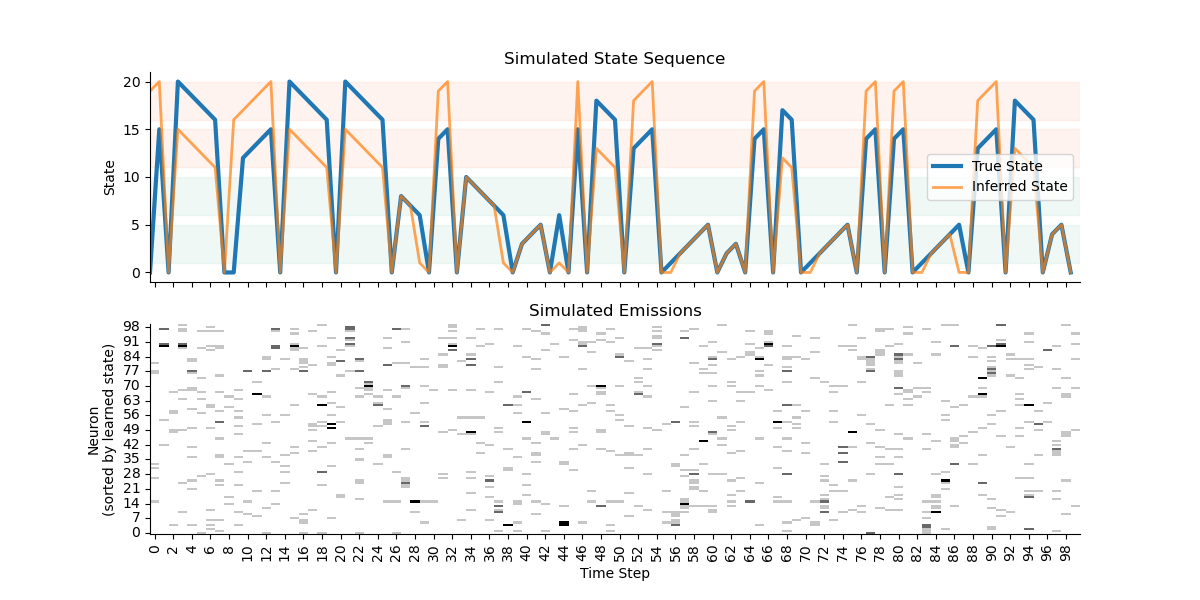

In [13]:
# sort the inferred states according to the optimal assignment
mapping = dict(zip(col_ind, row_ind))

inferred_states_sorted = np.array([
    mapping[s] for s in np.array(inferred_states)
])

# plot the latent trajectory and the correspodning emissions for the best model sorted by the optimal assignment
sorted_indices = col_ind

# sort the neurons based on their assigned states and plot the emissions again
learned_emission_prob_sorted = learned_emission_prob[sorted_indices]
neuron_sorted_indices = np.argsort(np.argmax(learned_emission_prob_sorted, axis=0))


fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# plot the true state sequence and the inferred state sequence on top of each other
sns.lineplot(x=np.arange(plot_len), y=states[:plot_len], ax=axs[0], linewidth=3, label="True State")
sns.lineplot(x=np.arange(plot_len), y=inferred_states_sorted[:plot_len], ax=axs[0], linewidth=2, alpha=0.7, label="Inferred State")
axs[0].set_title("Simulated State Sequence")
axs[0].set_ylabel("State")
axs[0].legend()

# plot the emissions sorted by the optimal assignment
sns.heatmap(emissions[:plot_len, neuron_sorted_indices].T, cmap="Greys", ax=axs[1], vmax = 3)
axs[1].invert_yaxis()
axs[1].set_title("Simulated Emissions")
axs[1].set_xlabel("Time Step")
axs[1].set_ylabel("Neuron\n(sorted by learned state)")
# remove colorbar
axs[1].collections[0].colorbar.remove()
# shade the regions of the plot corresponding to the sequences
for i in range(nSequences):
    # forward states
    forward_start = 1 + i * 2 * sequenceLength
    forward_end = forward_start + sequenceLength

    # cloned reverse states
    reverse_start = forward_end
    reverse_end = reverse_start + sequenceLength

    axs[0].axhspan(forward_start, forward_end - 1, color = seq_colors[i], alpha=0.1)
    axs[0].axhspan(reverse_start, reverse_end - 1, color = seq_colors[i], alpha=0.1)
sns.despine()
plt.show()
